# 🌌 **Clusterization Of Data**

## 📥 **1. Import libraries**

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors

In [56]:
! pip install opendatasets

In [57]:
import opendatasets as od

## ♻️ **2. Dataset processing**

In [58]:
od.download('https://www.kaggle.com/datasets/imanjowkar/clustering')

Skipping, found downloaded files in "./clustering" (use force=True to force download)


In [59]:
df = pd.read_csv('/content/clustering/Clustering.csv')

In [60]:
df.shape

(190, 3)

In [61]:
df.head()

,Unnamed: 0,x,y
0,1,3.367596,3.536694
1,2,2.667870,4.479919
2,3,1.344171,3.282591
3,4,1.389414,4.683227
4,5,1.644644,4.320822


In [62]:
del df['Unnamed: 0']

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       190 non-null    float64
 1   y       190 non-null    float64
dtypes: float64(2)
memory usage: 3.1 KB


In [64]:
df.describe()

,x,y
count,190.000000,190.000000
mean,4.721308,6.345303
std,3.294171,3.614820
min,-1.428115,-0.476742
25%,1.713220,3.126976
50%,3.462090,4.697728
75%,7.858967,9.802251
max,10.674577,12.894445


## 🧑🏻‍🎨 **3. Data visualization**

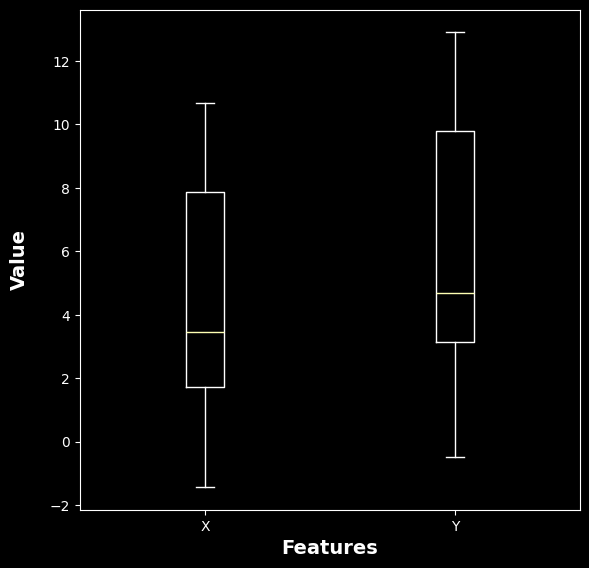

In [97]:
plt.style.use('dark_background')

figure = plt.figure(figsize = (5, 5))

axes = figure.add_axes([0, 0, 1, 1])
axes.boxplot(df, tick_labels = ['X', 'Y'])
axes.set_xlabel('Features', fontweight = 'bold', fontsize = 14)
axes.set_ylabel('Value', fontweight = 'bold', labelpad = 15, fontsize = 14)

plt.show()

- The median value of **X** ~ $3.5$.
- The median value of **Y** ~ $4.7$.

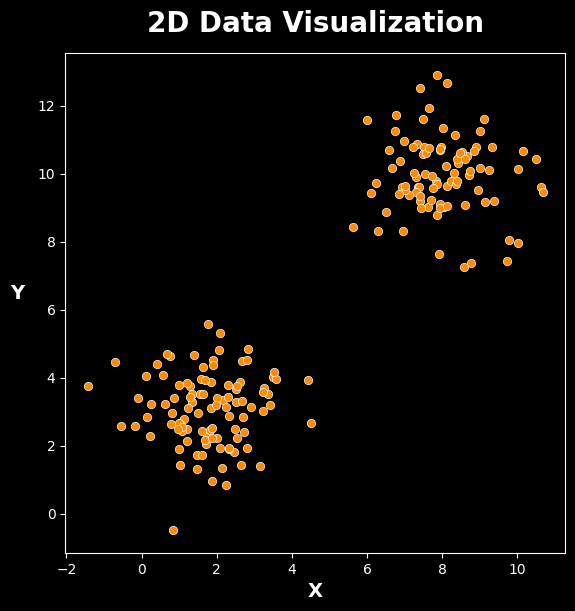

In [66]:
plt.style.use('dark_background')

figure = plt.figure(figsize = (5, 5))

axes = figure.add_axes([0, 0, 1, 1])
sns.scatterplot(data = df, x = 'x', y = 'y', color = '#FF8C00', ax = axes)
axes.set_xlabel('X', fontweight = 'bold', fontsize = 14)
axes.set_ylabel('Y', fontweight = 'bold', labelpad = 15, fontsize = 14, rotation = 0)
axes.set_title('2D Data Visualization', fontweight = 'bold', pad = 15, fontsize = 20)

plt.show()

- We see that the data is grouped into two groups with small outliers.

## 💪🏾 **4. The elbow method**

In [67]:
N = 11

inertia = []

for index in range(1, N):
  kmeans = KMeans(n_clusters = index)
  kmeans.fit(df)
  inertia.append(kmeans.inertia_)

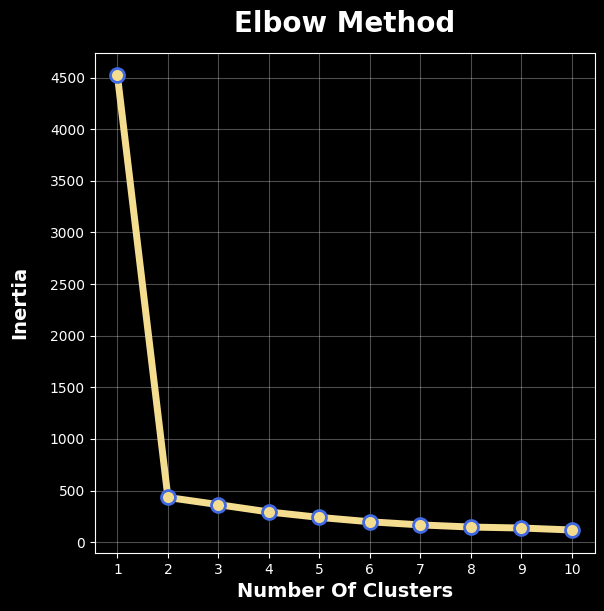

In [68]:
plt.style.use('dark_background')

xticks = np.arange(1, N)
yticks = np.arange(0, max(inertia), 500)

figure = plt.figure(figsize = (5, 5))

axes = figure.add_axes([0, 0, 1, 1])
axes.plot(xticks, inertia, marker = 'o', linestyle = '-', linewidth = 5, color = '#F5DD90',
          markeredgecolor = '#4169E1', markersize = 10, markeredgewidth = 2
          )
axes.set_xlabel('Number Of Clusters', fontweight = 'bold', fontsize = 14)
axes.set_ylabel('Inertia', fontweight = 'bold', labelpad = 15, fontsize = 14)
axes.set_title('Elbow Method', fontweight = 'bold', pad = 15, fontsize = 20)
axes.xaxis.set_ticks(xticks)
axes.yaxis.set_ticks(yticks)
axes.grid(alpha = 0.3)

plt.show()

- The optimal value for the number of clusters is $2$, since inertia does not drop so much after it.

## 𓃵 **5. Clustering using K-Means**

In [69]:
kmeans = KMeans(n_clusters = 2)
clusters = kmeans.fit_predict(df)

In [70]:
labels_dictionary = {0: 'First Cluster', 1: 'Second Cluster'}

In [71]:
labels = list(labels_dictionary.get(cluster) for cluster in clusters)

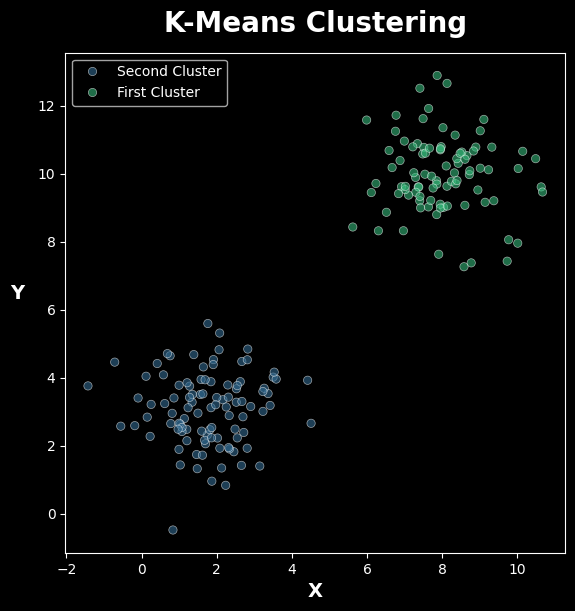

In [72]:
plt.style.use('dark_background')

figure = plt.figure(figsize = (5, 5))

axes = figure.add_axes([0, 0, 1, 1])
sns.scatterplot(data = df, x = 'x', y = 'y', hue = labels, alpha = 0.6, palette = 'viridis', ax = axes)
axes.set_xlabel('X', fontweight = 'bold', fontsize = 14)
axes.set_ylabel('Y', fontweight = 'bold', labelpad = 15, fontsize = 14, rotation = 0)
axes.set_title('K-Means Сlustering', fontweight = 'bold', pad = 15, fontsize = 20)

plt.show()

- We see the grouping in two clusters.

## 𓃮 **6. Finding hyperparameters**

In [73]:
def plot_k_distance_graph(data, number_of_neighbors):
  neighbors = NearestNeighbors(n_neighbors = number_of_neighbors)
  neighbors.fit(data)
  distances, _ = neighbors.kneighbors(data)
  distances = sorted(distances[:, number_of_neighbors - 1], reverse = True)

  plt.style.use('dark_background')

  figure = plt.figure(figsize = (5, 5))

  axes = figure.add_axes([0, 0, 1, 1])
  axes.plot(distances, linestyle = '-', linewidth = 5, color = '#483D8B')
  axes.set_xlabel('Points', fontweight = 'bold', fontsize = 14)
  axes.set_ylabel('Distance', fontweight = 'bold', labelpad = 15, fontsize = 14)
  axes.set_title(f'Distance To {number_of_neighbors}th Nearest Neighbor', fontweight = 'bold', pad = 15, fontsize = 20)
  axes.grid(axis = 'y', alpha = 0.3)

  plt.show()

In [74]:
min_samples = 2 * df.shape[1]

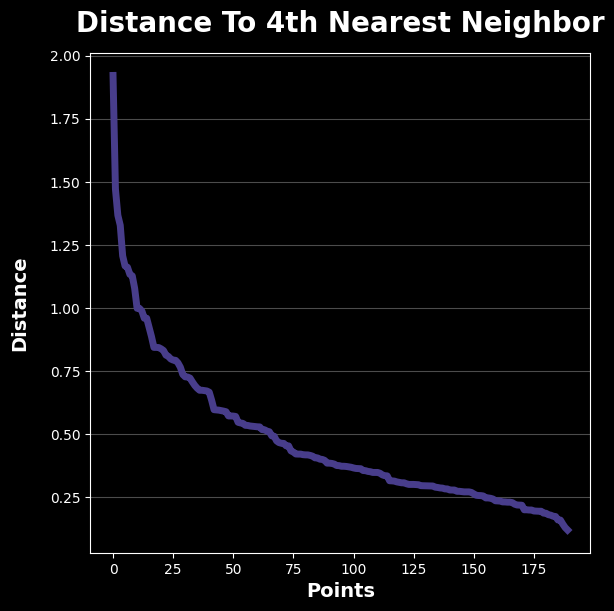

In [75]:
plot_k_distance_graph(df, min_samples)

- The optimal epsilon value for DBSCAN from the graph is approximately $0.6$, since after it the distance to the $4$th nearest neighbor does not drop so much.

In [76]:
epsilon = 0.6

## 🛰️ **7. Clustering using DBSCAN**

In [77]:
dbscan = DBSCAN(eps = epsilon, min_samples = min_samples)
clusters = dbscan.fit_predict(df)

In [78]:
labels_dictionary = {-1: 'Noise', 0: 'First Cluster', 1: 'Second Cluster'}

In [79]:
labels = list(labels_dictionary.get(cluster) for cluster in clusters)

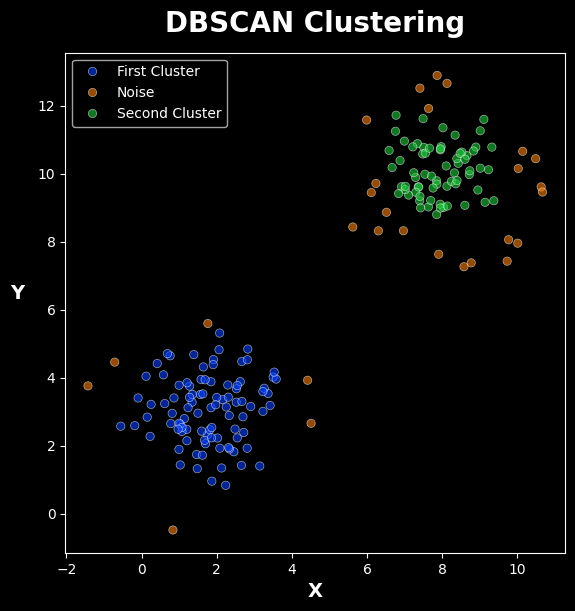

In [80]:
plt.style.use('dark_background')

figure = plt.figure(figsize = (5, 5))

axes = figure.add_axes([0, 0, 1, 1])
sns.scatterplot(data = df, x = 'x', y = 'y', hue = labels, alpha = 0.6, palette = 'bright', ax = axes)
axes.set_xlabel('X', fontweight = 'bold', fontsize = 14)
axes.set_ylabel('Y', fontweight = 'bold', labelpad = 15, fontsize = 14, rotation = 0)
axes.set_title('DBSCAN Сlustering', fontweight = 'bold', pad = 15, fontsize = 20)

plt.show()

- DBSCAN split the data into two clusters + found $28$ noise points that do not belong to any of the clusters.

In [81]:
number_of_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)

In [98]:
print(f'Number of clusters: {number_of_clusters}')

Number of clusters: 2


In [82]:
number_of_noise = list(clusters).count(-1)

In [99]:
print(f'Number of noise points: {number_of_noise}')

Number of noise points: 28


## 🦄 **8. Conclusion**

- After visualizing the data, we realized that we have two main clusters of data. At the same time, I would choose the DBSCAN results as true, since we see that we have points that are very far from the clusters and they need to be taken into account. There are only $28$ of them.